# Umbrella Sampling on a Protein-like Molecule

### Reconstructing a folding free-energy landscape along the radius of gyration $R_g$

This notebook is a self-contained, from-scratch demonstration of **umbrella sampling**, one of
the workhorse *enhanced-sampling* methods of computational chemistry and biophysics. We use it to
map the free-energy profile (the **potential of mean force**, PMF) of a small "protein-like"
molecule as it folds and unfolds.

**What you will see**

1. A coarse-grained **bead–spring polymer** in 2D that plays the role of a protein. It has a
   compact *folded* state and an extended *unfolded* state, separated by a free-energy **barrier
   whose height we can dial up or down**.
2. The **collective variable (CV)** is the molecule's **radius of gyration** $R_g$ — a genuine
   many-body quantity computed from all the bead coordinates.
3. Plain **Brownian dynamics** (overdamped Langevin). One section shows that when the barrier is
   tall, ordinary simulation **gets stuck in one basin** and cannot map the landscape — the
   *rare-event / sampling problem*.
4. **Umbrella sampling + WHAM**, which shatters that problem by running many short *biased*
   simulations and stitching them back together into the correct, unbiased PMF.

---

## The problem in one paragraph

The equilibrium probability of finding the molecule at a given $R_g$ is Boltzmann-distributed,
$P(R_g)\propto e^{-G(R_g)/k_BT}$, so the free-energy profile is

$$ G(R_g) \;=\; -k_BT\,\ln P(R_g) \;+\; \text{const.} $$

To estimate $P(R_g)$ by brute force you must *visit* every value of $R_g$ many times. But the
probability of sitting on top of a barrier of height $\Delta G^\ddagger$ is suppressed by
$e^{-\Delta G^\ddagger/k_BT}$, and the mean time to cross it grows **exponentially** (Kramers):
$\tau \sim e^{\Delta G^\ddagger/k_BT}$. A 12 $k_BT$ barrier is $\sim e^{12}\approx 1.6\times10^5$
times slower to cross than a flat region — so an unbiased run essentially never samples the
transition, and the PMF there is unknown.

## The umbrella-sampling idea

Add a **harmonic biasing potential** that tethers the CV near a chosen value $R_g^{(i)}$ in
*window* $i$:

$$ w_i(R_g) = \tfrac{1}{2}K\,(R_g - R_g^{(i)})^2 . $$

Each window is forced to sample a small slice of the CV — *including the barrier top* — cheaply.
Placing overlapping windows across the whole range and then removing the known bias (with the
**Weighted Histogram Analysis Method, WHAM**) reconstructs the true, unbiased $G(R_g)$. The cost of
this is **independent of the barrier height**, which is the whole point.

Let's build it.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

rng_global = np.random.default_rng(12345)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.25, "axes.axisbelow": True,
})

# Consistent colors used throughout
C_FOLD, C_UNFOLD, C_BARR = "#2c6fbb", "#c0392b", "#555555"
C_UMB, C_TRUE, C_UNBIAS = "#8e44ad", "#111111", "#e67e22"

# -------------------------------------------------------------------
# QUICK toggle. As shipped the notebook is pre-run at full quality, so
# every figure and number below is publication-grade. If you just want to
# re-run everything quickly to see the mechanics (slightly noisier curves,
# ~1-2 min instead of ~4-5), set
#     QUICK = True
# and run all cells.
# -------------------------------------------------------------------
QUICK = False
S = 0.6 if QUICK else 1.0          # global sampling-length scale
def scaled(n, floor=2500):         # scale a step count by S
    return max(int(n * S), floor)
print(f"QUICK={QUICK}  (sampling scale S={S})")

QUICK=False  (sampling scale S=1.0)


## 2. The molecule: a tunable bead–spring "protein"

Our molecule is a chain of $N$ beads in 2D. The potential energy has three parts:

**(a) Bonds** hold consecutive beads together:
$\;U_{\text{bond}} = \tfrac12 k_b \sum_i (|\mathbf r_{i+1}-\mathbf r_i| - b_0)^2.$

**(b) Excluded volume** (a soft repulsion between non-bonded beads) gives the chain volume, so the
folded state is a compact globule rather than a collapsed point:
$\;U_{\text{ev}} = \tfrac12 k_{ev}\sum_{|i-j|\ge 2}(\sigma - r_{ij})^2\,\Theta(\sigma - r_{ij}).$

**(c) A shaping potential on the collective variable** $R_g$ itself. This is the knob that creates
folded/unfolded basins with a **tunable barrier**. We use a quartic double well,

$$ U_{\text{cv}}(R_g) = B\left[\Big(\tfrac{R_g - s_{\text{mid}}}{w}\Big)^2 - 1\right]^2, $$

which has minima at $R_g = s_{\text{mid}}\pm w$ (our folded and unfolded sizes) and a barrier of
height **exactly $B$** (in units of $k_BT$) at $R_g=s_{\text{mid}}$. Changing $B$ raises or lowers
the folding barrier while leaving the basin *locations* fixed — ideal for illustration.

> Because $U_{\text{cv}}$ depends only on the CV, it is legitimate to include it in the Hamiltonian
> and still treat $R_g$ as a genuine collective variable: the forces on individual beads follow from
> the chain rule, $\mathbf F_i = -\dfrac{dU_{\text{cv}}}{dR_g}\dfrac{\partial R_g}{\partial\mathbf r_i}.$

### Radius of gyration and its gradient

$$ R_g = \sqrt{\tfrac1N\sum_i |\mathbf r_i - \mathbf r_{\text{cm}}|^2}, \qquad
   \frac{\partial R_g}{\partial \mathbf r_i} = \frac{\mathbf r_i - \mathbf r_{\text{cm}}}{N\,R_g}. $$

In [2]:
class Params:
    # --- molecule ---
    N       = 15         # number of beads
    dim     = 2          # 2D for easy visualization
    b0      = 1.0        # bond rest length
    k_bond  = 50.0       # bond force constant  [kT / length^2]
    sig_ev  = 0.9        # excluded-volume diameter
    k_ev    = 25.0       # excluded-volume stiffness
    # --- CV double well: U_cv = B * ((Rg - s_mid)/half_w)^2 - 1)^2 ---
    s_mid   = 2.5        # barrier location in Rg
    half_w  = 1.0        # folded well = s_mid - half_w ; unfolded = s_mid + half_w
    barrier = 12.0       # <<< TUNABLE barrier height B, in units of kT >>>
    # --- thermodynamics / integrator ---
    kT      = 1.0
    D       = 1.0        # diffusion constant = kT / gamma  (we set gamma = 1)
    dt      = 0.005

FOLDED_RG   = Params.s_mid - Params.half_w    # ~1.5
UNFOLDED_RG = Params.s_mid + Params.half_w    # ~3.5
print(f"folded Rg ~ {FOLDED_RG},  unfolded Rg ~ {UNFOLDED_RG},  barrier at Rg = {Params.s_mid}")

def rg_and_grad(pos, N):
    cm   = pos.mean(axis=0)
    disp = pos - cm
    Rg   = np.sqrt((disp**2).sum() / N)
    grad = disp / (N * Rg)                 # dRg / d r_i
    return Rg, grad

def U_cv_of_Rg(Rg, p, barrier=None):
    B = p.barrier if barrier is None else barrier
    u = (Rg - p.s_mid) / p.half_w
    return B * (u**2 - 1.0)**2

def potential_energy(pos, p, barrier=None, bias_k=0.0, bias_c=0.0):
    '''Total potential energy (used for sanity-checking the forces).'''
    B = p.barrier if barrier is None else barrier
    # bonds
    d = pos[1:] - pos[:-1]
    r = np.linalg.norm(d, axis=1)
    U = 0.5 * p.k_bond * ((r - p.b0)**2).sum()
    # excluded volume
    diff = pos[:, None, :] - pos[None, :, :]
    dist = np.sqrt((diff**2).sum(-1) + 1e-12)
    sep  = np.abs(np.arange(p.N)[:, None] - np.arange(p.N)[None, :])
    m    = (sep >= 2) & (dist < p.sig_ev)
    U += 0.5 * p.k_ev * (np.where(m, (p.sig_ev - dist), 0.0)**2).sum() / 2.0
    # CV double well + umbrella bias
    Rg, _ = rg_and_grad(pos, p.N)
    U += U_cv_of_Rg(Rg, p, barrier=B) + 0.5 * bias_k * (Rg - bias_c)**2
    return U

def forces(pos, p, barrier=None, bias_k=0.0, bias_c=0.0):
    '''Return (forces, Rg).  F = -grad U.'''
    B = p.barrier if barrier is None else barrier
    N = p.N
    F = np.zeros_like(pos)
    # --- bonds ---
    d = pos[1:] - pos[:-1]
    r = np.linalg.norm(d, axis=1)
    coef = (p.k_bond * (r - p.b0) / r)[:, None]
    fvec = coef * d
    F[:-1] += fvec
    F[1:]  -= fvec
    # --- excluded volume (non-bonded pairs, |i-j| >= 2) ---
    diff = pos[:, None, :] - pos[None, :, :]
    dist = np.sqrt((diff**2).sum(-1) + 1e-12)
    sep  = np.abs(np.arange(N)[:, None] - np.arange(N)[None, :])
    m    = (sep >= 2) & (dist < p.sig_ev)
    np.fill_diagonal(m, False)
    if m.any():
        mag = np.where(m, p.k_ev * (p.sig_ev - dist), 0.0) / dist
        F  += (mag[:, :, None] * diff).sum(axis=1)
    # --- CV double well + optional umbrella bias ---
    Rg, grad = rg_and_grad(pos, N)
    u = (Rg - p.s_mid) / p.half_w
    dUcv_dRg = 4.0 * B * u * (u**2 - 1.0) / p.half_w
    dU_dRg   = dUcv_dRg + bias_k * (Rg - bias_c)
    F += -dU_dRg * grad
    return F, Rg

# --- sanity check: analytic forces vs finite-difference gradient ---
p = Params()
_pos = rng_global.normal(size=(p.N, p.dim)) * 0.7
_pos[:, 0] += np.arange(p.N) * 0.8
Fana, _ = forces(_pos, p, bias_k=5.0, bias_c=2.0)
eps = 1e-6; Fnum = np.zeros_like(_pos)
for i in range(p.N):
    for a in range(p.dim):
        d = np.zeros_like(_pos); d[i, a] = eps
        Up = potential_energy(_pos + d, p, bias_k=5.0, bias_c=2.0)
        Um = potential_energy(_pos - d, p, bias_k=5.0, bias_c=2.0)
        Fnum[i, a] = -(Up - Um) / (2 * eps)
print("max |analytic - finite-difference| force error:",
      f"{np.abs(Fana - Fnum).max():.2e}   (should be ~1e-6)")

folded Rg ~ 1.5,  unfolded Rg ~ 3.5,  barrier at Rg = 2.5
max |analytic - finite-difference| force error: 9.80e-08   (should be ~1e-6)


## 3. What the molecule looks like

Let's generate a **folded** and an **unfolded** configuration and draw them. These are honest
2D bead chains; $R_g$ is computed directly from their coordinates.

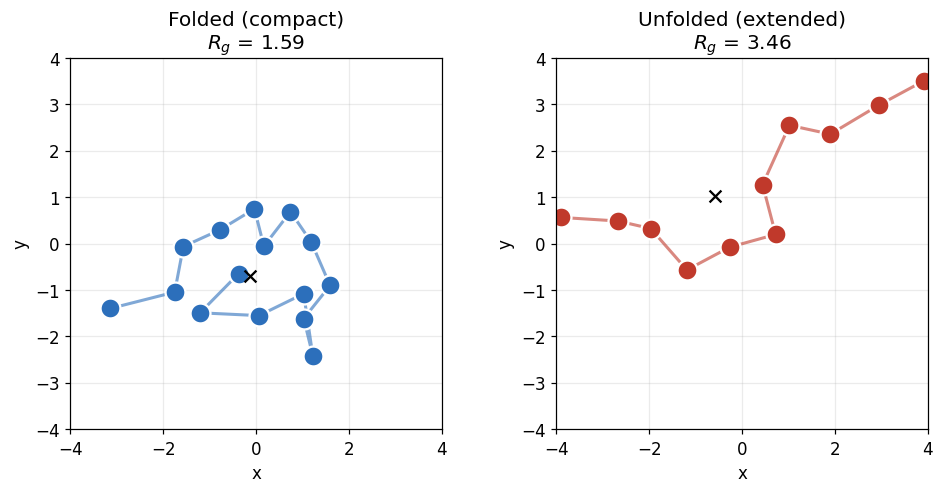

In [3]:
def init_line(p, spacing=None):
    spacing = p.b0 if spacing is None else spacing
    pos = np.zeros((p.N, p.dim)); pos[:, 0] = np.arange(p.N) * spacing
    return pos - pos.mean(0)

def init_folded(p, rng):
    pos = np.zeros((p.N, p.dim)); ang = 0.0
    for i in range(1, p.N):
        ang += rng.uniform(-1.8, 1.8)
        pos[i] = pos[i-1] + p.b0 * np.array([np.cos(ang), np.sin(ang)])
    return pos - pos.mean(0)

# We'll define the integrator in the next section; for now, relax two
# configs toward target sizes with a strong restraint using a tiny inline loop.
def _quick_relax(pos, p, target, K=150.0, steps=3000, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    pos = pos.copy(); c = np.sqrt(2 * p.D * p.dt)
    for _ in range(steps):
        F, _ = forces(pos, p, bias_k=K, bias_c=target)
        pos += (p.D / p.kT) * F * p.dt + c * rng.standard_normal(pos.shape)
    return pos

p = Params()
pos_fold   = _quick_relax(init_folded(p, np.random.default_rng(1)), p, FOLDED_RG,   rng=np.random.default_rng(2))
pos_unfold = _quick_relax(init_line(p),                              p, UNFOLDED_RG, rng=np.random.default_rng(3))

def draw_chain(ax, pos, color, title):
    ax.plot(pos[:, 0], pos[:, 1], "-", color=color, lw=2, alpha=0.6, zorder=1)
    ax.scatter(pos[:, 0], pos[:, 1], s=170, color=color, edgecolor="white",
               linewidth=1.5, zorder=2)
    ax.scatter([pos[:,0].mean()], [pos[:,1].mean()], marker="x", color="k", s=60, zorder=3)
    Rg, _ = rg_and_grad(pos, p.N)
    ax.set_title(f"{title}\n$R_g$ = {Rg:.2f}"); ax.set_aspect("equal")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
draw_chain(axes[0], pos_fold,   C_FOLD,   "Folded (compact)")
draw_chain(axes[1], pos_unfold, C_UNFOLD, "Unfolded (extended)")
for ax in axes: ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()

## 4. The tunable landscape

Here is the shaping potential $U_{\text{cv}}(R_g)$ for several barrier heights $B$. The basin
positions stay fixed at $R_g\approx1.5$ (folded) and $R_g\approx3.5$ (unfolded); only the barrier
between them changes. Later we will run the dynamics at a **low** barrier (where brute force works)
and a **high** barrier (where it fails).

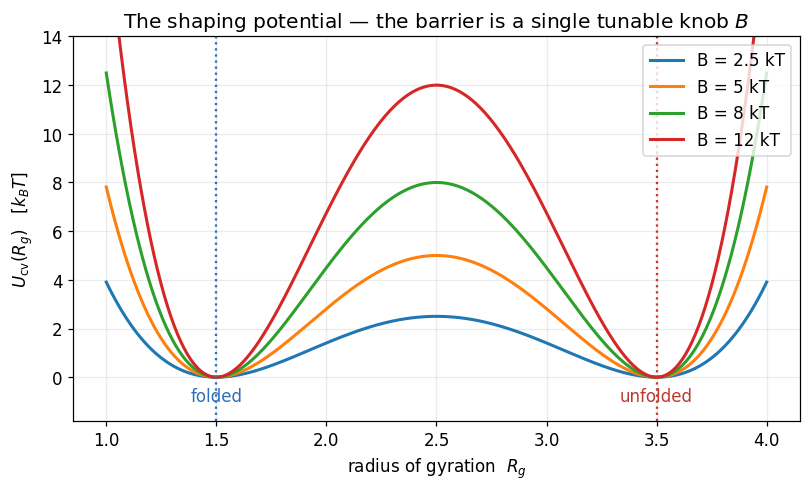

In [4]:
p = Params()
grid = np.linspace(1.0, 4.0, 400)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for B in [2.5, 5, 8, 12]:
    ax.plot(grid, U_cv_of_Rg(grid, p, barrier=B), lw=2,
            label=f"B = {B} kT")
ax.axvline(FOLDED_RG,   color=C_FOLD,   ls=":", lw=1.5)
ax.axvline(UNFOLDED_RG, color=C_UNFOLD, ls=":", lw=1.5)
ax.text(FOLDED_RG,  -1.0, "folded",   color=C_FOLD,   ha="center")
ax.text(UNFOLDED_RG,-1.0, "unfolded", color=C_UNFOLD, ha="center")
ax.set_xlabel(r"radius of gyration  $R_g$")
ax.set_ylabel(r"$U_{\mathrm{cv}}(R_g)$   [$k_BT$]")
ax.set_title("The shaping potential — the barrier is a single tunable knob $B$")
ax.legend(); ax.set_ylim(-1.8, 14); plt.tight_layout(); plt.show()

## 5. Brownian dynamics integrator

We propagate the beads with **overdamped Langevin dynamics** (Brownian dynamics), the
high-friction limit of Langevin dynamics in which inertia is negligible:

$$ \mathbf r_i(t+\Delta t) = \mathbf r_i(t) + \frac{D}{k_BT}\,\mathbf F_i\,\Delta t
   \;+\; \sqrt{2D\,\Delta t}\;\boldsymbol\xi_i,\qquad \boldsymbol\xi_i\sim\mathcal N(0,1). $$

The Gaussian noise term is what makes the molecule explore configuration space and reach thermal
equilibrium. With $D = k_BT/\gamma$ and our units ($k_BT=1,\ \gamma=1$) this is a plain
Euler–Maruyama step. An optional harmonic **bias** on $R_g$ (the umbrella restraint) can be switched
on with `bias_k`, `bias_c`.

In [5]:

def make_config_at(p, target, K=150.0, steps=None, seed=0):
    '''Prepare a configuration with a chosen R_g by biased relaxation.'''
    steps = scaled(4000, floor=2000) if steps is None else steps
    rng = np.random.default_rng(seed)
    return bd_run(init_folded(p, rng), p, steps, bias_k=K, bias_c=target, rng=rng)[0]

# # tiny smoke test
# p = Params()
# _pos, _rg = bd_run(init_line(p), p, scaled(3000), barrier=0.0,
#                    rng=np.random.default_rng(0), record_every=5)
# print(f"smoke test OK: recorded {_rg.size} Rg values, "
#       f"mean {_rg.mean():.2f}, range ({_rg.min():.2f}, {_rg.max():.2f})")

  Run overdamped Langevin (Brownian) dynamics once while optionally recording Rg values, coordinate snapshots, and animation frames.

Parameters

    pos : np.ndarray
        Initial particle coordinates. Expected shape is typically (N, d).

    p : object
        Parameter object containing at least:
            p.D   : diffusion coefficient
            p.dt  : integration timestep
            p.kT  : thermal energy

    nsteps : int
        Number of production steps after equilibration.

    barrier : optional
        Barrier passed to forces().

    bias_k : float
        Harmonic bias force constant.

    bias_c : float
        Harmonic bias center.

    record_every : int
        Record Rg every this many production steps.

    equil : int
        Number of equilibration steps. Equilibration data are not recorded.

    n_snapshots : int
        Number of coordinate snapshots to save during production.
        Set to 0 to disable snapshots.

    animate : bool
        Whether to save frames for animation.

    anim_frames : int
        Number of animation frames to save.

    rng : np.random.Generator, optional
        NumPy random-number generator.

    Returns
    -------
    final_pos : np.ndarray
        Final particle coordinates.

    rg_t : np.ndarray
        Recorded Rg values.

    t : np.ndarray
        Times corresponding to rg_t.

    snaps : list[np.ndarray]
        Saved coordinate snapshots.

    snap_info : list[tuple]
        Tuples containing (time, Rg) for each snapshot.

    frames : list[tuple]
        Tuples containing (coordinates, Rg, time) for animation.
  

In [6]:
def bd_run(pos, p, nsteps, barrier=None, bias_k=0.0, bias_c=0.0,
           record_every=10, equil=0, n_snapshots=0,
           animate=False, anim_frames=0, rng=None):
    """
    Run overdamped Langevin (Brownian) dynamics once while recording:
      - Rg as a function of time
      - selected coordinate snapshots
      - selected animation frames

    Returns
    -------
    final_pos, rg_t, t, snaps, snap_info, frames
    """
    rng = np.random.default_rng() if rng is None else rng
    pos, cnoise = pos.copy(), np.sqrt(2.0 * p.D * p.dt)

    # Production-step indices at which snapshots/frames are stored
    snap_steps = set(np.linspace(0, nsteps-1, min(n_snapshots, nsteps)).astype(int)) \
                 if nsteps > 0 and n_snapshots > 0 else set()
    frame_steps = set(np.linspace(0, nsteps-1, min(anim_frames, nsteps)).astype(int)) \
                  if animate and nsteps > 0 and anim_frames > 0 else set()

    rg_t, times, snaps, snap_info, frames = [], [], [], [], []

    for step in range(nsteps + equil):
        # Compute force and advance one Brownian-dynamics step
        F, _ = forces(pos, p, barrier=barrier, bias_k=bias_k, bias_c=bias_c)
        pos += (p.D / p.kT) * F * p.dt + cnoise * rng.standard_normal(pos.shape)

        # Do not record equilibration
        if step < equil:
            continue

        s, time = step - equil, (step - equil + 1) * p.dt

        # Recompute Rg only when something needs to be recorded.
        # This ensures Rg matches the updated coordinates.
        if s % record_every == 0 or s in snap_steps or s in frame_steps:
            _, Rg = forces(pos, p, barrier=barrier,
                           bias_k=bias_k, bias_c=bias_c)

        if s % record_every == 0:
            rg_t.append(Rg); times.append(time)

        if s in snap_steps:
            snaps.append(pos.copy()); snap_info.append((time, Rg))

        if s in frame_steps:
            frames.append((pos.copy(), Rg, time))

    return pos, np.asarray(rg_t), np.asarray(times), snaps, snap_info, frames

In [7]:
def visualize_trajectory(t, rg_t, snaps, snap_info, frames, p=None, *,
                         barrier=None, bias_k=0.0, bias_c=0.0,
                         animate=False, anim_interval=60,
                         movie_only=False, title=None):
    """Visualize an already-completed Brownian-dynamics trajectory.

    t, rg_t   : recorded Rg trajectory from bd_run.
    snaps     : saved coordinate snapshots.
    snap_info : list of (time, Rg) values corresponding to snapshots.
    frames    : saved animation frames from bd_run.
    p         : Params instance.
    animate   : render an inline movie using the stored frames.
    movie_only: show only the movie; implies animate=True.
    Returns   : dict containing the supplied trajectory data and optional anim.
    """
    p = Params() if p is None else p
    B = p.barrier if barrier is None else barrier
    fold, unfold = p.s_mid - p.half_w, p.s_mid + p.half_w
    rg_t, t = np.asarray(rg_t), np.asarray(t)

    if movie_only:
        animate = True

    # --- colors ---
    cF = globals().get("C_FOLD", "#2c6fbb")
    cU = globals().get("C_UNFOLD", "#c0392b")
    cB = globals().get("C_BARR", "#555555")
    cmap_rg = mcolors.LinearSegmentedColormap.from_list("fu", [cF, "#b8b8b8", cU])
    norm = plt.Normalize(fold - 0.4, unfold + 0.4)

    def _chain(ax, cfg, color):
        cfg = cfg - cfg.mean(0)
        ax.plot(cfg[:, 0], cfg[:, 1], "-", color=color,
                lw=1.5, alpha=0.55, zorder=1)
        ax.scatter(cfg[:, 0], cfg[:, 1], s=55, color=color,
                   edgecolor="white", linewidth=0.8, zorder=2)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)

    # --- static overview: Rg(t), histogram, and snapshots ---
    if not movie_only:
        n_snapshots = len(snaps)
        fig_w = min(20, max(11, 2.1 * max(n_snapshots, 1)))
        fig = plt.figure(figsize=(fig_w, 6))
        import matplotlib.gridspec as gridspec
        outer = gridspec.GridSpec(2, 1, height_ratios=[1.2, 1.0], hspace=0.42)

        top = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=outer[0], width_ratios=[5, 1], wspace=0.06
        )
        axt = fig.add_subplot(top[0])
        axh = fig.add_subplot(top[1], sharey=axt)

        axt.axhspan(fold - 0.35, fold + 0.35, color=cF, alpha=0.10)
        axt.axhspan(unfold - 0.35, unfold + 0.35, color=cU, alpha=0.10)
        axt.axhline(p.s_mid, color=cB, ls="--", lw=1, alpha=0.6)
        axt.plot(t, rg_t, color="#333333", lw=0.8)

        axt.text(t[-1], fold, " folded", va="center", color=cF, fontsize=9)
        axt.text(t[-1], unfold, " unfolded", va="center", color=cU, fontsize=9)

        for ts, rgs in snap_info:
            axt.axvline(ts, color="k", lw=0.8, alpha=0.2)
            axt.plot(ts, rgs, "o", color=cmap_rg(norm(rgs)), ms=7,
                     markeredgecolor="k", markeredgewidth=0.6, zorder=5)

        axt.set_xlabel("time"); axt.set_ylabel(r"$R_g(t)$")
        axt.set_ylim(min(1.0, rg_t.min() - 0.2),
                     max(4.2, rg_t.max() + 0.2))

        bias_txt = "" if bias_k == 0 else rf", restraint $K={bias_k:g}$ @ {bias_c:g}"
        axt.set_title(title or
                      rf"Brownian-dynamics trajectory ($B={B:g}\,k_BT${bias_txt})")

        axh.hist(rg_t, bins=40, orientation="horizontal",
                 color="#7f8c8d", alpha=0.85, density=True)
        axh.set_xlabel("density")
        axh.tick_params(labelleft=False)
        axh.set_title("sampled $R_g$", fontsize=9)

        # Snapshot montage
        if n_snapshots:
            bot = gridspec.GridSpecFromSubplotSpec(
                1, n_snapshots, subplot_spec=outer[1], wspace=0.15
            )
            for i, (cfg, (ts, rgs)) in enumerate(zip(snaps, snap_info)):
                axs = fig.add_subplot(bot[i])
                _chain(axs, cfg, cmap_rg(norm(rgs)))
                axs.set_title(f"t={ts:.0f}\n$R_g$={rgs:.2f}", fontsize=8.5)

        plt.show()

    # --- trajectory statistics ---
    n_cross = int(np.abs(np.diff((rg_t > p.s_mid).astype(int))).sum())
    print(f"{rg_t.size} points over {t[-1]:.0f} time units | "
          f"barrier crossings: {n_cross} | "
          f"Rg sampled in [{rg_t.min():.2f}, {rg_t.max():.2f}]")

    out = dict(t=t, rg=rg_t, snaps=snaps,
               snap_info=snap_info, frames=frames)

    # --- optional inline movie from stored frames ---
    if animate:
        if len(frames) == 0:
            raise ValueError(
                "No animation frames were recorded. Run bd_run with "
                "animate=True and anim_frames > 0."
            )

        from matplotlib import animation
        from IPython.display import HTML, display

        figA, axA = plt.subplots(figsize=(4.4, 4.4))

        def _upd(k):
            axA.clear()
            cfg, rgv, tv = frames[k]
            _chain(axA, cfg, cmap_rg(norm(rgv)))
            axA.set_title(f"t = {tv:.1f}    $R_g$ = {rgv:.2f}")

        anim = animation.FuncAnimation(
            figA, _upd, frames=len(frames), interval=anim_interval
        )
        html = anim.to_jshtml()
        plt.close(figA)
        display(HTML(html))
        out["anim"] = anim

    return out

## 6. Straightforward simulation — and why it struggles

Now the central point. We run **ordinary, unbiased** Brownian dynamics and try to read off the free
energy directly from the histogram of $R_g$, using $G(R_g) = -k_BT\ln P(R_g)$.

### 6a. Low barrier ($B=2.5\,k_BT$): brute force works

With a small barrier the molecule hops back and forth between folded and unfolded many times in a
single trajectory. The histogram is bimodal and the recovered PMF is trustworthy.

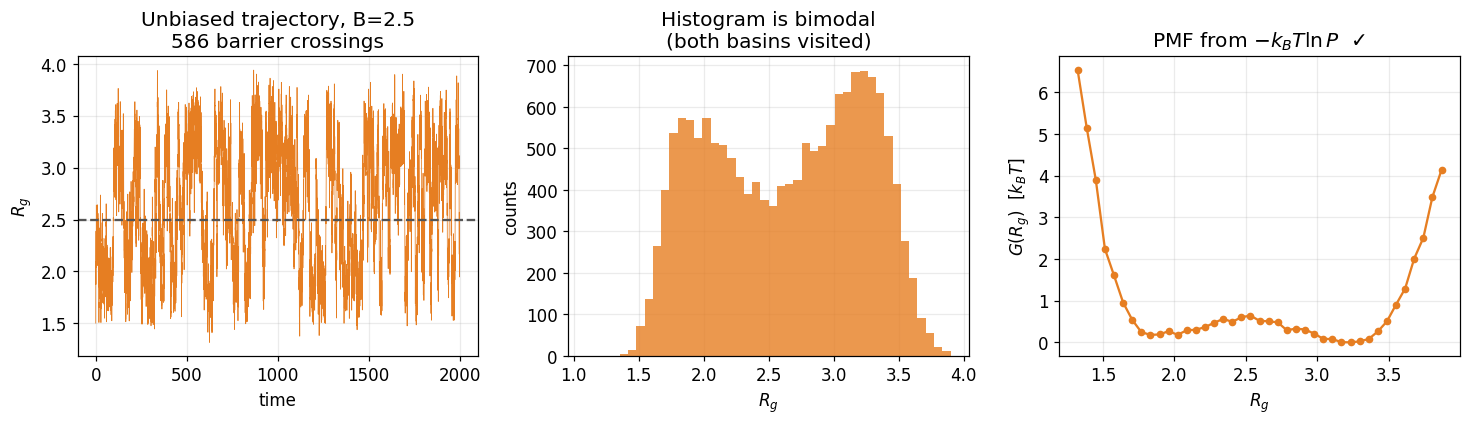

Low barrier: 586 crossings


In [8]:
p_lo = Params(); p_lo.barrier = 2.5
pos0  = make_config_at(p_lo, FOLDED_RG, seed=11)
# running the brownian dynamics simulation
nsteps = 400000
stride = 100
n_snapshots = 6
anim_frames = 500

pos_final, rg_lo, t, snaps, snap_info, frames = bd_run(
    pos0, p_lo, scaled(400000),
    barrier=p_lo.barrier,
    record_every=25,
    n_snapshots=8,      # optional static snapshots
    animate=True,
    anim_frames=150,    # number of saved movie frames
    rng=np.random.default_rng(21)
)

# transitions across the barrier
side = rg_lo > p_lo.s_mid
n_cross_lo = int(np.abs(np.diff(side.astype(int))).sum())

# PMF straight from the (unbiased) histogram
def pmf_from_samples(samples, bins):
    h, edges = np.histogram(samples, bins=bins, density=True)
    ctr = 0.5 * (edges[:-1] + edges[1:])
    with np.errstate(divide="ignore"):
        G = -np.log(h)
    G = np.where(np.isfinite(G), G, np.nan)
    G -= np.nanmin(G)
    return ctr, G, h

bins = np.linspace(1.1, 3.9, 45)
ctr_lo, G_lo, h_lo = pmf_from_samples(rg_lo, bins)

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
ax[0].plot(t, rg_lo, lw=0.5, color=C_UNBIAS)
ax[0].axhline(p_lo.s_mid, color=C_BARR, ls="--")
ax[0].set_xlabel("time"); ax[0].set_ylabel(r"$R_g$")
ax[0].set_title(f"Unbiased trajectory, B=2.5\n{n_cross_lo} barrier crossings")
ax[1].hist(rg_lo, bins=bins, color=C_UNBIAS, alpha=0.8)
ax[1].set_xlabel(r"$R_g$"); ax[1].set_ylabel("counts")
ax[1].set_title("Histogram is bimodal\n(both basins visited)")
ax[2].plot(ctr_lo, G_lo, "o-", color=C_UNBIAS, ms=4)
ax[2].set_xlabel(r"$R_g$"); ax[2].set_ylabel(r"$G(R_g)$  [$k_BT$]")
ax[2].set_title(r"PMF from $-k_BT\ln P$  ✓")
plt.tight_layout(); plt.show()
print(f"Low barrier: {n_cross_lo} crossings")

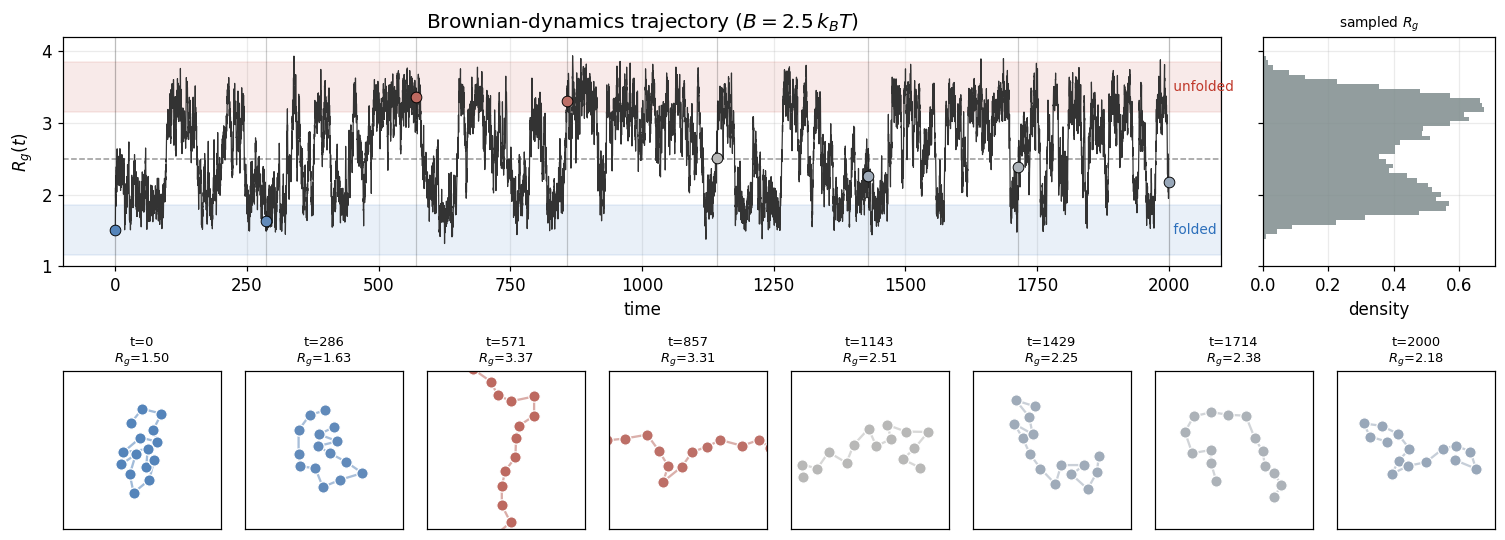

16000 points over 2000 time units | barrier crossings: 586 | Rg sampled in [1.32, 3.94]


In [9]:
traj_lo = visualize_trajectory(
    t=t, rg_t=rg_lo, snaps=snaps, snap_info=snap_info, frames=frames,
    p=p_lo,
    animate=False,
    anim_interval=40
)

In [10]:
traj_lo = visualize_trajectory(
    t, rg_lo, snaps, snap_info, frames,
    p=p_lo,
    movie_only=True,
    anim_interval=40
)

Output hidden; open in https://colab.research.google.com to view.

### 6b. High barrier ($B=12\,k_BT$): brute force fails

Now we raise the barrier. We launch **several independent walkers**, some from the folded basin and
some from the unfolded basin, and run each for the *same* budget. Watch what happens: the walkers
**never cross**. Each one is trapped in the basin it started in. The combined histogram has a gaping
hole over the barrier, and the naive PMF is simply **undefined** there — brute-force sampling has
failed.

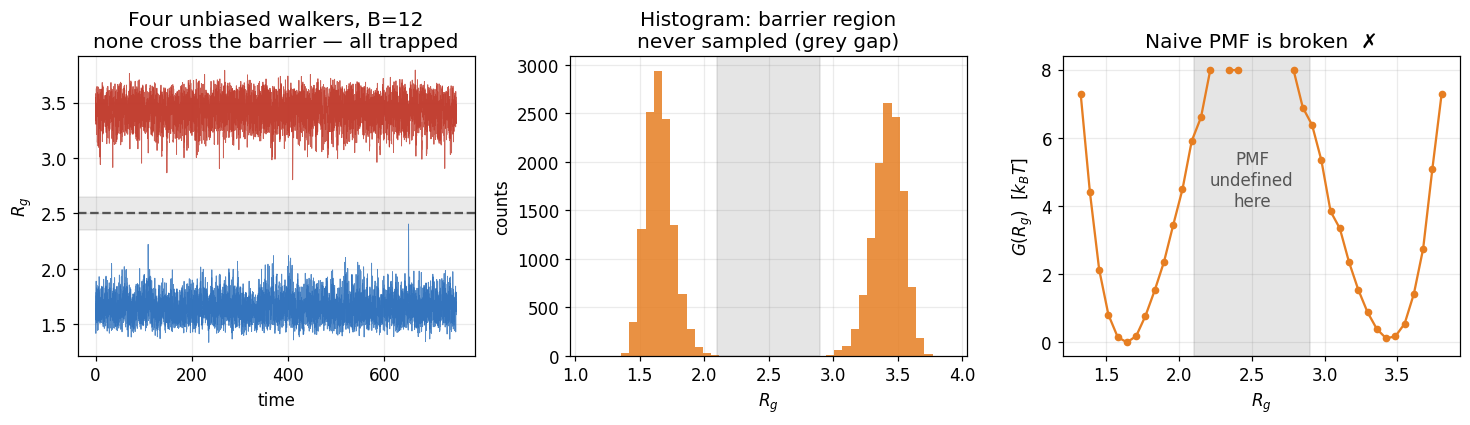

High barrier: the transition state and barrier height are simply unknown.


In [11]:
p_hi = Params(); p_hi.barrier = 12.0
walkers = []
starts  = [("folded", FOLDED_RG, C_FOLD), ("folded", FOLDED_RG, C_FOLD),
           ("unfolded", UNFOLDED_RG, C_UNFOLD), ("unfolded", UNFOLDED_RG, C_UNFOLD)]
for k, (name, tgt, col) in enumerate(starts):
    pos0 = make_config_at(p_hi, tgt, seed=30 + k)
    pos_final, rg_hi, t, snaps_hi, snap_info_hi, frames_hi = bd_run(pos0, p_hi,
                    scaled(150000), barrier = p_hi.barrier,
                   record_every = 25, n_snapshots = 8, animate=True,
                   rng=np.random.default_rng(40 + k), anim_frames=150)
    walkers.append((name, col, rg_hi))

all_hi = np.concatenate([w[2] for w in walkers])
side   = all_hi > p_hi.s_mid
n_cross_hi = int(np.abs(np.diff(side.astype(int))).sum())  # within concatenation (rough)

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
for name, col, rg in walkers:
    ax[0].plot(t, rg, lw=0.6, color=col, alpha=0.8)
ax[0].axhline(p_hi.s_mid, color=C_BARR, ls="--")
ax[0].axhspan(p_hi.s_mid-0.15, p_hi.s_mid+0.15, color=C_BARR, alpha=0.12)
ax[0].set_xlabel("time"); ax[0].set_ylabel(r"$R_g$")
ax[0].set_title("Four unbiased walkers, B=12\nnone cross the barrier — all trapped")
ax[1].hist(all_hi, bins=bins, color=C_UNBIAS, alpha=0.85)
ax[1].axvspan(p_hi.s_mid-0.4, p_hi.s_mid+0.4, color=C_BARR, alpha=0.15)
ax[1].set_xlabel(r"$R_g$"); ax[1].set_ylabel("counts")
ax[1].set_title("Histogram: barrier region\nnever sampled (grey gap)")
ctr_hi, G_hi, h_hi = pmf_from_samples(all_hi, bins)
ax[2].plot(ctr_hi, G_hi, "o-", color=C_UNBIAS, ms=4)
ax[2].axvspan(p_hi.s_mid-0.4, p_hi.s_mid+0.4, color=C_BARR, alpha=0.15)
ax[2].text(p_hi.s_mid, np.nanmax(G_hi)*0.5, "PMF\nundefined\nhere",
           ha="center", color=C_BARR)
ax[2].set_xlabel(r"$R_g$"); ax[2].set_ylabel(r"$G(R_g)$  [$k_BT$]")
ax[2].set_title(r"Naive PMF is broken  ✗")
plt.tight_layout(); plt.show()
print("High barrier: the transition state and barrier height are simply unknown.")



In [13]:
traj_hi = visualize_trajectory(
    t, rg_hi, snaps=snaps_hi, snap_info=snap_info_hi, frames=frames_hi,
    p=p_hi,
    movie_only=True,
    anim_interval=40
)


Output hidden; open in https://colab.research.google.com to view.

### 6c. Why it fails: the exponential wall

The reason isn't laziness of the integrator — it's physics. The rate of crossing a barrier of
height $\Delta G^\ddagger$ falls off exponentially, $k \sim e^{-\Delta G^\ddagger/k_BT}$. We can see
this directly by counting barrier crossings per unit time as we raise $B$.

### What exactly has failed at the high barrier?

The high-barrier trajectories can be well equilibrated *within* their starting basins while remaining unequilibrated *between* basins.

This distinction is central:

- **Local equilibration:** the trajectory samples configurations typical of one basin.
- **Global equilibration:** the trajectory also visits the other basin with the correct equilibrium frequency.
- **Ergodic sampling over the simulation time:** the trajectory explores all regions that materially contribute to the equilibrium average.

Increasing the barrier does not make the equilibrium distribution mathematically invalid. It makes transitions so rare that the finite trajectory cannot estimate that distribution reliably.

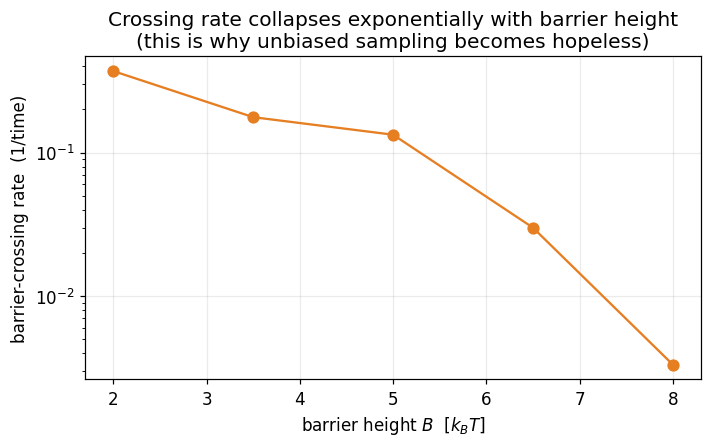

crossing rates: ['0.37', '0.177', '0.133', '0.03', '0.00333']


In [15]:
scan_B = [2.0, 3.5, 5.0, 6.5, 8.0]
cross_rate = []
for B in scan_B:
    pB = Params(); pB.barrier = B
    pos0 = make_config_at(pB, pB.s_mid, seed=77)   # start at the barrier top
    _, rg, t, _, _, _ = bd_run(pos0, pB, scaled(120000), barrier=pB.barrier, record_every=20,
                   rng=np.random.default_rng(88))

    side = rg > pB.s_mid
    nc = int(np.abs(np.diff(side.astype(int))).sum())
    T  = rg.size * 20 * pB.dt
    cross_rate.append(nc / T)

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.semilogy(scan_B, np.maximum(cross_rate, 1e-4), "o-", color=C_UNBIAS, ms=7)
ax.set_xlabel(r"barrier height $B$  [$k_BT$]")
ax.set_ylabel("barrier-crossing rate  (1/time)")
ax.set_title("Crossing rate collapses exponentially with barrier height\n"
             "(this is why unbiased sampling becomes hopeless)")
plt.tight_layout(); plt.show()
print("crossing rates:", [f"{r:.3g}" for r in cross_rate])

## 7. Umbrella sampling

The fix: don't wait for the molecule to *choose* to visit the barrier — **force** it to, one window
at a time.

**Recipe**

1. Choose a set of window centers $R_g^{(1)}<R_g^{(2)}<\dots$ spanning the whole CV range.
2. In window $i$, add the restraint $w_i(R_g)=\tfrac12 K(R_g-R_g^{(i)})^2$ and run a short biased
   simulation. The restraint parks the molecule near $R_g^{(i)}$ — *even on the barrier top* —
   producing a narrow, well-sampled histogram.
3. Make sure **adjacent histograms overlap** (choose $K$ and the spacing so the windows join up).
4. **Unbias and stitch** the windows together with WHAM to recover $G(R_g)$.

We initialize each window from the previous window's final configuration ("steered" start), which
walks the molecule smoothly from folded to unfolded and gives every window a good starting point.

### Deriving the umbrella-sampling distribution

Let the unbiased potential energy be $U_0(\mathbf q)$. In umbrella window $i$, add the harmonic restraint

$$w_i(s)=\frac{1}{2}K_i(s-c_i)^2.$$

Here:

- $i$ labels the umbrella window;
- $s=s(\mathbf q)$ is the collective variable;
- $c_i$ is the center of window $i$;
- $K_i$ is the harmonic force constant;
- $w_i(s)$ is the known biasing potential.

The total potential in window $i$ is

$$U_i^{\mathrm b}(\mathbf q)=U_0(\mathbf q)+w_i[s(\mathbf q)].$$

The biased configurational distribution is therefore

$$p_i^{\mathrm b}(\mathbf q)\propto \exp\{-\beta[U_0(\mathbf q)+w_i(s)]\}.$$

After projecting onto the collective variable,

$$P_i^{\mathrm b}(s)\propto P(s)\exp[-\beta w_i(s)].$$

The restraint increases sampling near $c_i$ and suppresses sampling far from $c_i$. It does not reveal the unbiased PMF by itself; it creates a deliberately altered distribution from which the original distribution must be reconstructed.

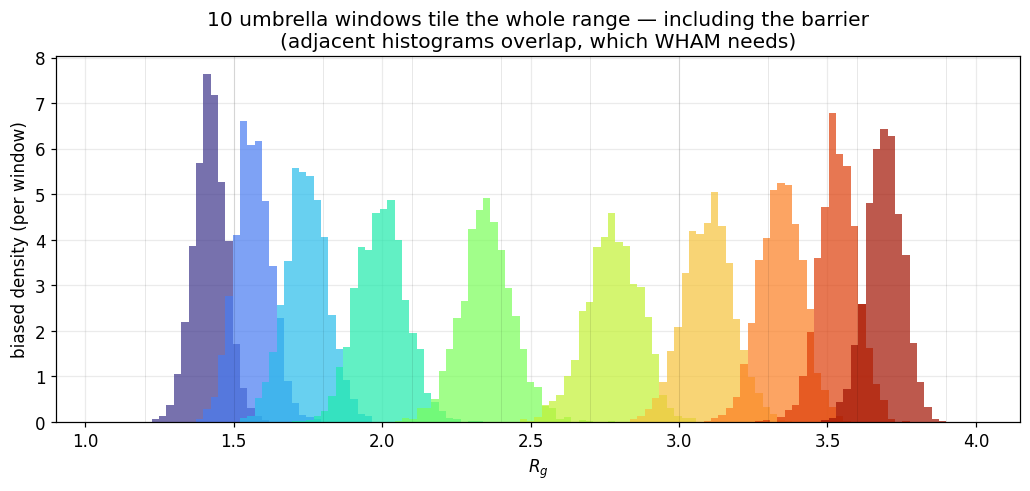

Total biased samples: 20,000   CV-range coverage: 91%


In [17]:
def run_umbrella(p, centers, K, nsteps, equil, record_every=10, seed=0, start=None):
    '''Sequential (steered) umbrella sampling. Returns list of Rg-sample arrays + last configs.'''
    rng = np.random.default_rng(seed)
    pos = init_folded(p, rng) if start is None else start.copy()
    # equilibrate into the first window
    pos, _, _, _, _, _= bd_run(pos, p, scaled(4000), bias_k=K, bias_c=centers[0], rng=rng)

    samples, finals = [], []
    for c in centers:
        pos, rg, _, _, _, _ = bd_run(pos, p, nsteps, bias_k=K, bias_c=c,
                         equil=equil, record_every=record_every, rng=rng)
        samples.append(rg); finals.append(pos.copy())
    return samples, finals

# --- window layout ---
N_WIN   = 10
centers = np.linspace(1.2, 3.9, N_WIN)
K_UMB   = 150.0

p_hi = Params(); p_hi.barrier = 12.0
umb_samples, umb_finals = run_umbrella(
    p_hi, centers, K_UMB,
    nsteps=scaled(20000), equil=scaled(5000, floor=1500),
    record_every=10, seed=101)

# --- show the overlapping window histograms ---
fig, ax = plt.subplots(figsize=(9.5, 4.6))
cmap = plt.cm.turbo(np.linspace(0.05, 0.95, N_WIN))
hbins = np.linspace(1.05, 4.0, 120)
for i, s in enumerate(umb_samples):
    ax.hist(s, bins=hbins, color=cmap[i], alpha=0.7,
            histtype="stepfilled", density=True)
for c in centers:
    ax.axvline(c, color="k", lw=0.4, alpha=0.15)
ax.set_xlabel(r"$R_g$"); ax.set_ylabel("biased density (per window)")
ax.set_title(f"{N_WIN} umbrella windows tile the whole range — including the barrier\n"
             "(adjacent histograms overlap, which WHAM needs)")
plt.tight_layout(); plt.show()

occupancy = np.mean(np.histogram(np.concatenate(umb_samples), bins=hbins)[0] > 0)
print(f"Total biased samples: {sum(s.size for s in umb_samples):,}   "
      f"CV-range coverage: {occupancy:.0%}")

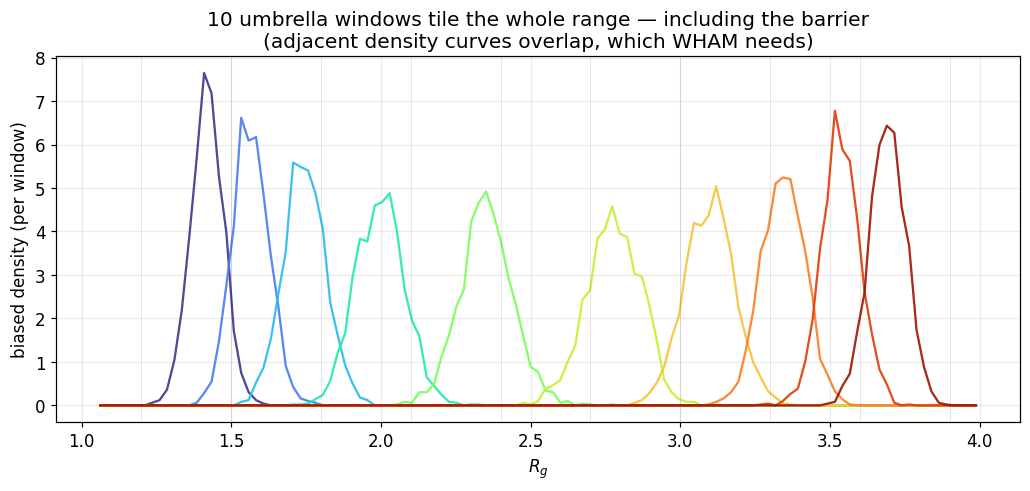

Total biased samples: 20,000   CV-range coverage: 91%


In [18]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

cmap = plt.cm.turbo(np.linspace(0.05, 0.95, N_WIN))
hbins = np.linspace(1.05, 4.0, 120)

# Bin centers for plotting smooth-looking density lines
bin_centers = 0.5 * (hbins[:-1] + hbins[1:])

for i, s in enumerate(umb_samples):
    density, _ = np.histogram(s, bins=hbins, density=True)

    ax.plot(
        bin_centers,
        density,
        color=cmap[i],
        lw=1.5,
        alpha=0.9
    )

for c in centers:
    ax.axvline(c, color="k", lw=0.4, alpha=0.15)

ax.set_xlabel(r"$R_g$")
ax.set_ylabel("biased density (per window)")
ax.set_title(
    f"{N_WIN} umbrella windows tile the whole range — including the barrier\n"
    "(adjacent density curves overlap, which WHAM needs)"
)

plt.tight_layout()
plt.show()

occupancy = np.mean(np.histogram(np.concatenate(umb_samples), bins=hbins)[0] > 0)

print(
    f"Total biased samples: {sum(s.size for s in umb_samples):,}   "
    f"CV-range coverage: {occupancy:.0%}"
)

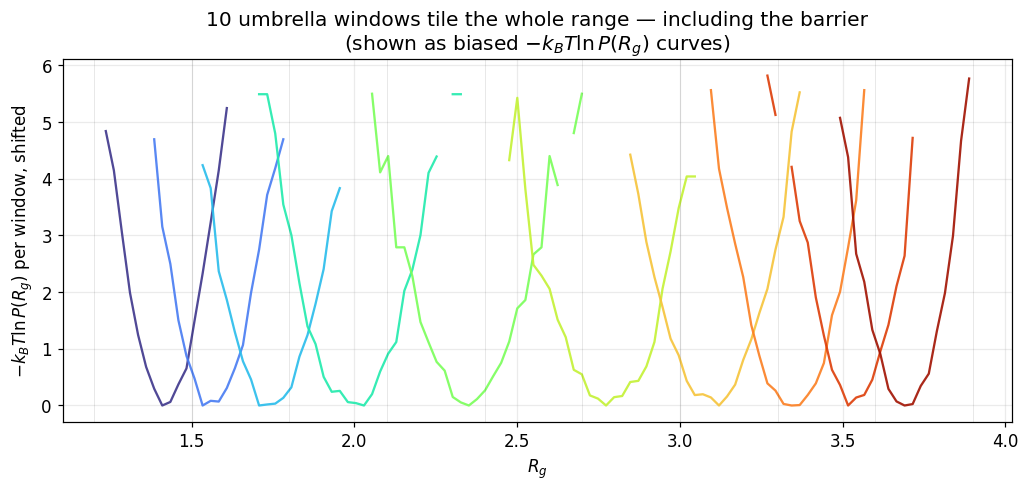

Total biased samples: 20,000   CV-range coverage: 91%


In [19]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

cmap = plt.cm.turbo(np.linspace(0.05, 0.95, N_WIN))
hbins = np.linspace(1.05, 4.0, 120)

# Bin centers for plotting lines
bin_centers = 0.5 * (hbins[:-1] + hbins[1:])

# Choose units for kBT
# If you want reduced units, leave this as 1.0
kBT = 1.0

# If you want kcal/mol at 300 K, use instead:
# kBT = 0.0019872041 * 300.0

for i, s in enumerate(umb_samples):
    density, _ = np.histogram(s, bins=hbins, density=True)

    # Convert biased probability density to biased free energy
    F = np.full_like(density, np.nan, dtype=float)

    nonzero = density > 0
    F[nonzero] = -kBT * np.log(density[nonzero])

    # Shift each window so its minimum is zero
    # This makes the line shapes easier to compare
    F -= np.nanmin(F)

    ax.plot(
        bin_centers,
        F,
        color=cmap[i],
        lw=1.5,
        alpha=0.9
    )

for c in centers:
    ax.axvline(c, color="k", lw=0.4, alpha=0.15)

ax.set_xlabel(r"$R_g$")
ax.set_ylabel(r"$-k_BT \ln P(R_g)$ per window, shifted")
ax.set_title(
    f"{N_WIN} umbrella windows tile the whole range — including the barrier\n"
    r"(shown as biased $-k_BT \ln P(R_g)$ curves)"
)

plt.tight_layout()
plt.show()

occupancy = np.mean(np.histogram(np.concatenate(umb_samples), bins=hbins)[0] > 0)

print(
    f"Total biased samples: {sum(s.size for s in umb_samples):,}   "
    f"CV-range coverage: {occupancy:.0%}"
)

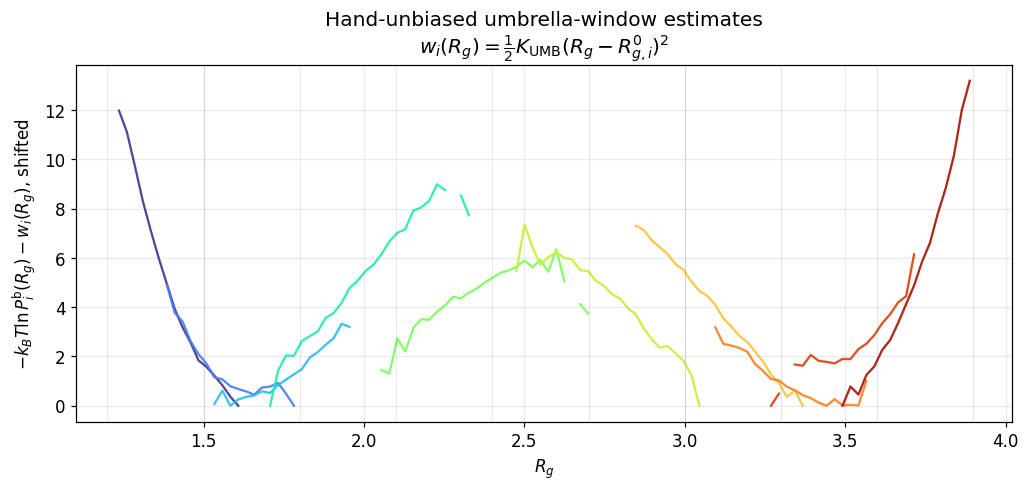

Total biased samples: 20,000   CV-range coverage: 91%


In [20]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

cmap = plt.cm.turbo(np.linspace(0.05, 0.95, N_WIN))

# Use the notebook temperature
kBT = p_hi.kT

for i, s in enumerate(umb_samples):
    density, _ = np.histogram(s, bins=hbins, density=True)

    # Biased free energy from the sampled biased probability
    F_biased = np.full_like(density, np.nan, dtype=float)
    nonzero = density > 0
    F_biased[nonzero] = -kBT * np.log(density[nonzero])

    # Harmonic umbrella bias for this window
    # w_i(Rg) = 1/2 K_UMB (Rg - center_i)^2
    w_umb = 0.5 * K_UMB * (bin_centers - centers[i])**2

    # Hand-unbiased estimate for this window
    F_unbiased_hand = F_biased - w_umb

    # Each window still has an arbitrary additive constant.
    # Shift each curve so its minimum is zero for visual comparison.
    F_unbiased_hand -= np.nanmin(F_unbiased_hand)

    ax.plot(
        bin_centers,
        F_unbiased_hand,
        color=cmap[i],
        lw=1.5,
        alpha=0.9
    )

for c in centers:
    ax.axvline(c, color="k", lw=0.4, alpha=0.15)

ax.set_xlabel(r"$R_g$")
ax.set_ylabel(r"$-k_BT\ln P_i^\mathrm{b}(R_g) - w_i(R_g)$, shifted")
ax.set_title(
    f"Hand-unbiased umbrella-window estimates\n"
    r"$w_i(R_g)=\frac{1}{2}K_\mathrm{UMB}(R_g-R_{g,i}^0)^2$"
)

plt.tight_layout()
plt.show()

occupancy = np.mean(np.histogram(np.concatenate(umb_samples), bins=hbins)[0] > 0)

print(
    f"Total biased samples: {sum(s.size for s in umb_samples):,}   "
    f"CV-range coverage: {occupancy:.0%}"
)

### Why hand-unbiasing gives the shape but not the absolute placement

Starting from

$$P_i^{\mathrm b}(s)\propto P(s)\exp[-\beta w_i(s)],$$

take $-k_BT\ln$ of both sides:

$$-k_BT\ln P_i^{\mathrm b}(s)=G(s)+w_i(s)+C_i.$$

Therefore, a local estimate of the unbiased profile is

$$G_i(s)=-k_BT\ln P_i^{\mathrm b}(s)-w_i(s)+C_i'.$$

Subtracting the umbrella potential removes the known curvature introduced by that window. However, every window retains a different unknown additive constant $C_i'$.

That is why the hand-unbiased curves can have compatible local shapes but cannot be stitched by simply setting every minimum to zero. The relative offsets must be inferred from regions where neighboring windows sample the same values of $s$.

## 8. Removing the bias: WHAM

Each window $i$ samples a *biased* distribution
$P_i^{\text{b}}(R_g)\propto P(R_g)\,e^{-w_i(R_g)/k_BT}$. The **Weighted Histogram Analysis Method**
finds the single unbiased $P(R_g)$ most consistent with all the windows at once, by solving these
coupled equations self-consistently:

$$
P(R_g) = \frac{\sum_i H_i(R_g)}
              {\sum_i N_i\,e^{(f_i - w_i(R_g))/k_BT}},
\qquad
e^{-f_i/k_BT} = \sum_{R_g} P(R_g)\,e^{-w_i(R_g)/k_BT},
$$

where $H_i$ is window $i$'s histogram, $N_i$ its sample count, and $f_i$ its (unknown) free-energy
offset. We iterate to convergence, then set $G(R_g) = -k_BT\ln P(R_g)$.

### WHAM in plain language

WHAM performs two jobs simultaneously:

1. It removes the known umbrella bias from every window.
2. It determines the relative free-energy offset between windows using their overlap.

A useful way to describe the iteration is:

- guess the window offsets;
- use those offsets to estimate one global unbiased distribution;
- use the global distribution to update the offsets;
- repeat until neither changes appreciably.

The histograms $H_i(s)$ provide the observed counts. The factors involving $w_i(s)$ describe how each window distorted the target distribution. The unknown $f_i$ values align the windows on one common free-energy scale.


In [21]:
def wham(samples_per_window, centers, K, kT=1.0, bins=None,
         tol=1e-9, maxiter=200000):
    S = len(centers)
    alls = np.concatenate(samples_per_window)
    if bins is None:
        bins = np.linspace(alls.min(), alls.max(), 61)
    xc = 0.5 * (bins[:-1] + bins[1:]); M = xc.size
    H  = np.zeros((S, M)); Nk = np.zeros(S)
    for i, s in enumerate(samples_per_window):
        H[i], _ = np.histogram(s, bins=bins); Nk[i] = H[i].sum()
    bias   = 0.5 * K * (xc[None, :] - np.asarray(centers)[:, None])**2  # (S,M)
    expneg = np.exp(-bias / kT)
    num    = H.sum(axis=0)
    f = np.zeros(S)
    for it in range(maxiter):
        denom = (Nk[:, None] * np.exp(f[:, None] / kT) * expneg).sum(axis=0)
        P = np.where(num > 0, num / np.maximum(denom, 1e-300), 0.0)
        P /= P.sum()
        f_new = -kT * np.log(np.maximum((expneg * P[None, :]).sum(axis=1), 1e-300))
        f_new -= f_new[0]
        if np.max(np.abs(f_new - f)) < tol:
            f = f_new; break
        f = f_new
    with np.errstate(divide="ignore"):
        G = -kT * np.log(P)
    G[num == 0] = np.nan            # mask unsampled bins instead of +inf
    G -= np.nanmin(G)
    return xc, G, P, H, bins, it

def barrier_height(xc, G, ts=(2.2, 2.8), folded=(1.3, 2.1)):
    '''Folding barrier = PMF at the transition state (Rg ~ 2.5) minus the
    floor of the folded (small-Rg) basin. Measuring at the *known* TS window
    keeps this robust against noisy, poorly sampled bins at the CV edges.'''
    top   = np.nanmax(G[(xc >= ts[0])     & (xc <= ts[1])])
    floor = np.nanmin(G[(xc >= folded[0])  & (xc <= folded[1])])
    return top - floor

def finterp(x, xp, fp):
    '''np.interp that ignores NaNs in fp.'''
    m = np.isfinite(fp)
    return np.interp(x, xp[m], fp[m])

wham_bins = np.linspace(1.2, 3.9, 45)
xc_umb, G_umb, P_umb, H_umb, _, iters = wham(umb_samples, centers, K_UMB,
                                             kT=p_hi.kT, bins=wham_bins)
print(f"WHAM converged in {iters} iterations.")
print(f"Recovered barrier height ~ {barrier_height(xc_umb, G_umb):.2f} kT")

WHAM converged in 3827 iterations.
Recovered barrier height ~ 9.22 kT


## 9. Establishing the ground truth (and validating WHAM)

How do we know the umbrella PMF is *right*? Two independent checks.

**Check 1 — an analytic reference.** Because $U_{\text{cv}}$ depends only on the CV, the true free
energy factorizes exactly:
$$ G(R_g;B) = F_{\text{intrinsic}}(R_g) + U_{\text{cv}}(R_g;B) + \text{const}, $$
where $F_{\text{intrinsic}}$ is the free energy of the **bare chain** (bonds + excluded volume +
chain entropy), independent of $B$. We measure $F_{\text{intrinsic}}$ once, by umbrella sampling
with the double well switched **off** ($B=0$). Then $F_{\text{intrinsic}} + U_{\text{cv}}(R_g;12)$
is a rigorous reference for the $B=12$ landscape.

**Check 2 — cross-validation at low barrier.** In the easy regime ($B=2.5$) we already have a
trustworthy brute-force PMF (Section 6a). Umbrella sampling at the *same* barrier must reproduce it.

In [22]:
# --- F_intrinsic: umbrella on the BARE chain (B = 0) ---
p0 = Params(); p0.barrier = 0.0
s0, _ = run_umbrella(p0, centers, K_UMB,
                     nsteps=scaled(20000), equil=scaled(5000, floor=1500),
                     record_every=10, seed=202)
xc0, F_intr, *_ = wham(s0, centers, K_UMB, kT=1.0, bins=wham_bins)

# analytic reference for B = 12
def zero_at_min(G):       # set the minimum (ignoring NaNs) to 0
    return G - np.nanmin(G)
ref_true    = zero_at_min(F_intr + U_cv_of_Rg(xc0, p_hi, barrier=12.0))
G_umb_shift = zero_at_min(G_umb)

mask = (xc_umb > 1.35) & (xc_umb < 3.75) & np.isfinite(G_umb_shift)
rmsd = np.sqrt(np.mean((finterp(xc_umb, xc0, ref_true)[mask] - G_umb_shift[mask])**2))
print(f"RMSD(umbrella vs analytic reference) over the barrier region = {rmsd:.2f} kT")

RMSD(umbrella vs analytic reference) over the barrier region = 0.30 kT


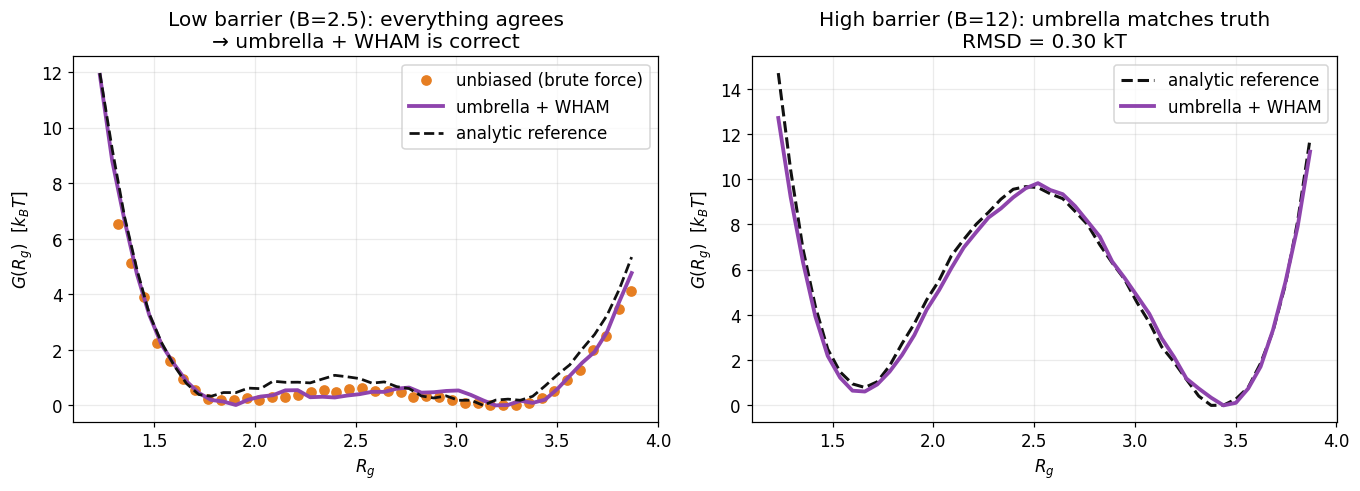

In [23]:
# --- Cross-validation at low barrier: unbiased vs umbrella ---
p_lo = Params(); p_lo.barrier = 2.5
s_lo_umb, _ = run_umbrella(p_lo, centers, K_UMB,
                           nsteps=scaled(14000), equil=scaled(4000, floor=1200),
                           record_every=10, seed=303)
xc_lo, G_lo_umb, *_ = wham(s_lo_umb, centers, K_UMB, kT=1.0, bins=wham_bins)
G_lo_umb = zero_at_min(G_lo_umb)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
# left: low barrier cross-check
G_lo_unb = zero_at_min(G_lo)
ax[0].plot(ctr_lo, G_lo_unb, "o", color=C_UNBIAS, ms=6, label="unbiased (brute force)")
ax[0].plot(xc_lo, G_lo_umb, "-", color=C_UMB, lw=2.5, label="umbrella + WHAM")
ax[0].plot(xc0, zero_at_min(F_intr + U_cv_of_Rg(xc0, p_lo, barrier=2.5)),
           "--", color=C_TRUE, lw=1.8, label="analytic reference")
ax[0].set_title("Low barrier (B=2.5): everything agrees\n→ umbrella + WHAM is correct")
ax[0].set_xlabel(r"$R_g$"); ax[0].set_ylabel(r"$G(R_g)$  [$k_BT$]"); ax[0].legend()

# right: high barrier umbrella vs reference
ax[1].plot(xc0, ref_true, "--", color=C_TRUE, lw=2, label="analytic reference")
ax[1].plot(xc_umb, G_umb_shift, "-", color=C_UMB, lw=2.5, label="umbrella + WHAM")
ax[1].set_title(f"High barrier (B=12): umbrella matches truth\nRMSD = {rmsd:.2f} kT")
ax[1].set_xlabel(r"$R_g$"); ax[1].set_ylabel(r"$G(R_g)$  [$k_BT$]"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. The payoff: brute force vs umbrella, side by side

This is the headline comparison at the **hard** barrier (imposed CV amplitude $B=12\,k_BT$; the
net barrier the chain actually feels, once its intrinsic free energy is included, is
$\approx 9\,k_BT$). The unbiased simulation (orange) only ever mapped one basin and left the barrier
blank. Umbrella sampling (purple) recovered the **entire** landscape — both basins, the transition
state, and the correct barrier height — matching the ground truth (black dashed).

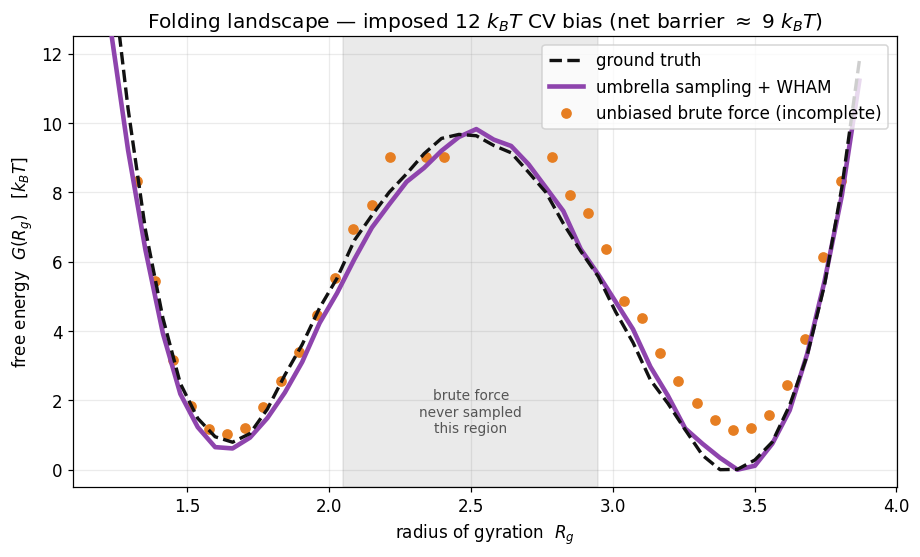

Total MD steps — unbiased (still failed): 600,000
Total MD steps — umbrella (full PMF):     254,000
With a comparable budget, umbrella mapped the barrier the unbiased run never touched.


In [24]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
# reference
ax.plot(xc0, ref_true, "--", color=C_TRUE, lw=2.2, label="ground truth", zorder=5)
# umbrella
ax.plot(xc_umb, G_umb_shift, "-", color=C_UMB, lw=3, label="umbrella sampling + WHAM", zorder=4)
# unbiased (broken) — align its folded basin to the reference for display
G_hi_disp = G_hi.copy()
fb = (ctr_hi < 2.0) & np.isfinite(G_hi_disp)
if fb.any():
    shift = finterp(ctr_hi[fb], xc0, ref_true).mean() - np.nanmean(G_hi_disp[fb])
    G_hi_disp = G_hi_disp + shift
ax.plot(ctr_hi, G_hi_disp, "o", color=C_UNBIAS, ms=6,
        label="unbiased brute force (incomplete)", zorder=3)
ax.axvspan(p_hi.s_mid-0.45, p_hi.s_mid+0.45, color=C_BARR, alpha=0.12)
ax.text(p_hi.s_mid, 1.0, "brute force\nnever sampled\nthis region",
        ha="center", va="bottom", color=C_BARR, fontsize=9)
ax.set_xlabel(r"radius of gyration  $R_g$")
ax.set_ylabel(r"free energy  $G(R_g)$   [$k_BT$]")
ax.set_title("Folding landscape — imposed 12 $k_BT$ CV bias "
             r"(net barrier $\approx$ 9 $k_BT$)")
ax.legend(loc="upper right"); ax.set_ylim(-0.5, 12.5)
plt.tight_layout(); plt.show()

steps_unbiased = scaled(150000) * 4
steps_umbrella = (scaled(20000) + scaled(5000, floor=1500)) * N_WIN + scaled(4000)
print(f"Total MD steps — unbiased (still failed): {steps_unbiased:,}")
print(f"Total MD steps — umbrella (full PMF):     {steps_umbrella:,}")
print(f"With a comparable budget, umbrella mapped the barrier the unbiased run never touched.")

## 11. Design choices that make or break umbrella sampling

Umbrella sampling has two knobs that matter: the **restraint strength $K$** and the **window spacing**.
They must be chosen together so that neighbouring windows *overlap*. WHAM literally cannot connect
two windows that don't share any sampled region.

Below we deliberately **delete a block of windows** near the barrier to open a gap. WHAM is then
flying blind across the hole, and the reconstructed barrier becomes unreliable — a vivid reminder
that **overlap is everything**.

### Practical design checklist

Before trusting an umbrella-sampling PMF, check the following.

**Coverage:** Do the windows span both basins and the barrier region?

**Overlap:** Does each window overlap with its neighbors? A continuous chain of overlap is needed across the full coordinate range.

**Within-window equilibration:** Did each window relax after the restraint was introduced?

**Correlation:** How many effectively independent samples were collected, rather than merely how many frames were saved?

**Starting-structure dependence:** Do windows initialized from different directions or independent structures agree?

**Restraint strength:** A very weak restraint may not hold the system near its center. A very stiff restraint produces narrow histograms and therefore requires more closely spaced windows.

**Orthogonal degrees of freedom:** Could hidden structural rearrangements remain trapped even while $R_g$ appears well sampled?

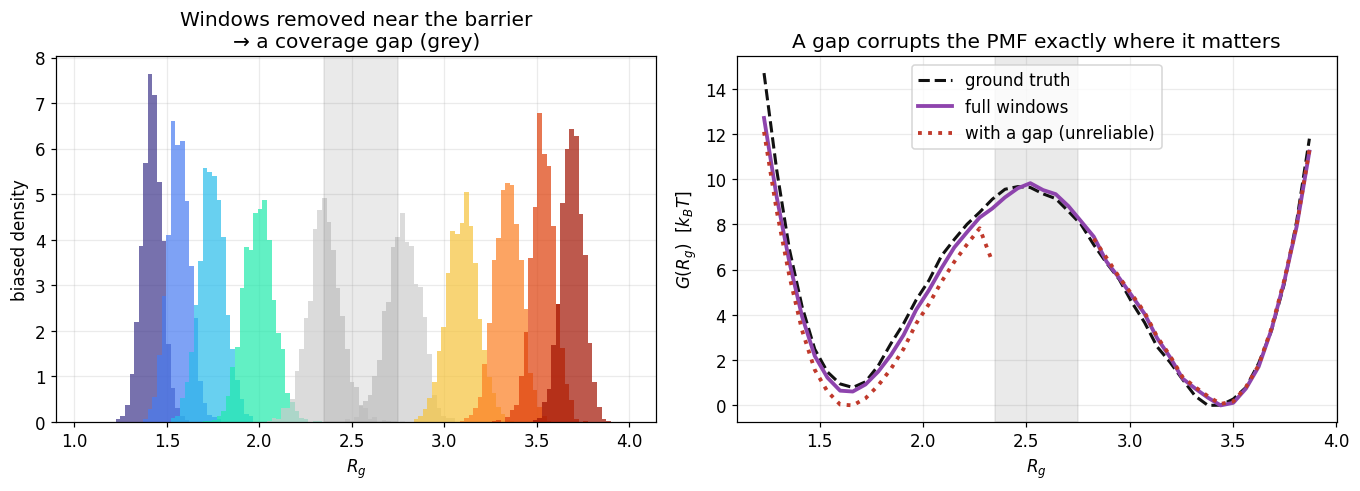

Removed window indices: [4 5]
Removed window centers: [2.4 2.7]


In [30]:
# Number of windows to remove around the barrier.
n_remove = 2

# Find the indices of the umbrella centers closest to the barrier location.
remove_indices = np.argsort(np.abs(centers - p_hi.s_mid))[:n_remove]

# Start by keeping all windows, then remove the selected barrier windows.
keep = np.ones(len(centers), dtype=bool)
keep[remove_indices] = False

# Retain only the centers and samples from the windows that were not removed.
cen_gap = centers[keep]
sam_gap = [umb_samples[i] for i in range(len(centers)) if keep[i]]

# Reconstruct the PMF using the incomplete set of umbrella windows.
xc_gap, G_gap, *_ = wham(
    sam_gap,
    cen_gap,
    K_UMB,
    kT=1.0,
    bins=wham_bins
)
G_gap = zero_at_min(G_gap)

# Determine the shaded region from the centers of the removed windows.
gap_left = centers[remove_indices].min() - 0.05
gap_right = centers[remove_indices].max() + 0.05

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))

# Assign one color to each original umbrella window.
cmap = plt.cm.turbo(np.linspace(0.05, 0.95, len(centers)))

# Plot all window histograms.
# Removed windows are shown in grey.
for i in range(len(centers)):
    color = cmap[i] if keep[i] else (0.8, 0.8, 0.8, 0.5)

    ax[0].hist(
        umb_samples[i],
        bins=hbins,
        color=color,
        alpha=0.7,
        histtype="stepfilled",
        density=True
    )

# Shade the region corresponding to the removed windows.
ax[0].axvspan(
    gap_left,
    gap_right,
    color=C_BARR,
    alpha=0.12
)

ax[0].set_title(
    "Windows removed near the barrier\n"
    "→ a coverage gap (grey)"
)
ax[0].set_xlabel(r"$R_g$")
ax[0].set_ylabel("biased density")

# Compare the complete and incomplete PMF reconstructions.
ax[1].plot(
    xc0,
    ref_true,
    "--",
    color=C_TRUE,
    lw=2,
    label="ground truth"
)

ax[1].plot(
    xc_umb,
    G_umb_shift,
    "-",
    color=C_UMB,
    lw=2.5,
    label="full windows"
)

ax[1].plot(
    xc_gap,
    G_gap,
    ":",
    color=C_UNFOLD,
    lw=2.5,
    label="with a gap (unreliable)"
)

# Shade the same missing region on the PMF plot.
ax[1].axvspan(
    gap_left,
    gap_right,
    color=C_BARR,
    alpha=0.12
)

ax[1].set_title(
    "A gap corrupts the PMF exactly where it matters"
)
ax[1].set_xlabel(r"$R_g$")
ax[1].set_ylabel(r"$G(R_g)$  [$k_BT$]")
ax[1].legend()

plt.tight_layout()
plt.show()

print("Removed window indices:", np.sort(remove_indices))
print("Removed window centers:", np.sort(centers[remove_indices]))

## 12. The key win: cost is independent of barrier height

Finally, we drive the barrier all the way from easy to very hard and reconstruct the PMF at each
value with the **same** umbrella protocol — same windows, same $K$, same per-window budget.

One subtlety worth stating plainly: the knob $B$ sets the amplitude of the *bias-shaping* term
$U_{\rm cv}$, but the **true folding barrier** the chain actually feels is
$U_{\rm cv}$ **plus the molecule's own intrinsic free energy** $F_{\rm int}(R_g)$ (measured in
Section 10). Because the compact folded basin is intrinsically a few $k_BT$ *less* favourable than
the transition region, the net barrier comes out a little below $B$. So the honest check is not
"recovered $=B$" but **recovered $=$ the analytic total barrier** $\;B+\Delta F_{\rm int}$.
That is what the right-hand panel verifies. The key practical point stands regardless:
**each calculation costs the same**, no matter how tall the barrier — exactly the regime where
brute force went from "slow" to "impossible" (Section 6c).

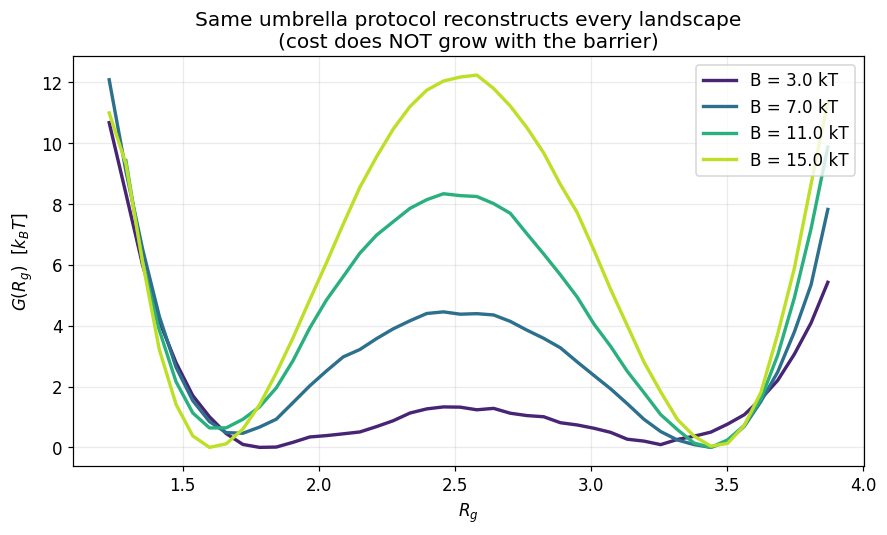

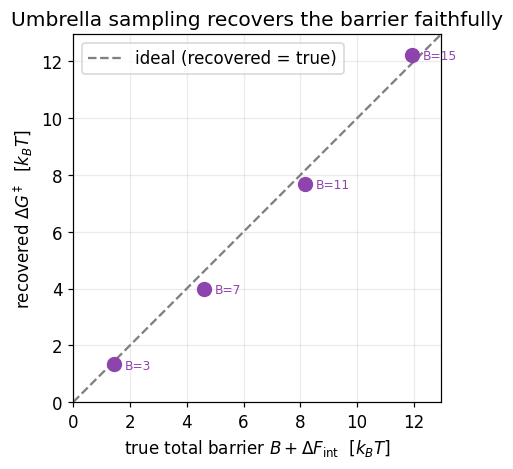

imposed CV amplitude B : [3.0, 7.0, 11.0, 15.0]
true total barrier     : [np.float64(1.5), np.float64(4.6), np.float64(8.2), np.float64(12.0)]
recovered (umbrella)   : [np.float64(1.3), np.float64(4.0), np.float64(7.7), np.float64(12.2)]


In [ ]:
barriers = [3.0, 7.0, 11.0, 15.0]
recovered, true_barrier = [], []
fig, ax = plt.subplots(figsize=(8.2, 5))
cmap2 = plt.cm.viridis(np.linspace(0.1, 0.9, len(barriers)))
for j, B in enumerate(barriers):
    pB = Params(); pB.barrier = B
    sB, _ = run_umbrella(pB, centers, K_UMB,
                         nsteps=scaled(11000), equil=scaled(3000, floor=1000),
                         record_every=10, seed=500 + j)
    xcB, GB, *_ = wham(sB, centers, K_UMB, kT=1.0, bins=wham_bins)
    GB = zero_at_min(GB)
    ax.plot(xcB, GB, "-", color=cmap2[j], lw=2.2, label=f"B = {B} kT")
    recovered.append(barrier_height(xcB, GB))
    # analytic total barrier for this B = intrinsic FE + CV bias
    true_pmf = zero_at_min(F_intr + U_cv_of_Rg(xc0, pB, barrier=B))
    true_barrier.append(barrier_height(xc0, true_pmf))
ax.set_xlabel(r"$R_g$"); ax.set_ylabel(r"$G(R_g)$  [$k_BT$]")
ax.set_title("Same umbrella protocol reconstructs every landscape\n"
             "(cost does NOT grow with the barrier)")
ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.6, 4.4))
lo, hi = 0, max(true_barrier) + 1
ax.plot([lo, hi], [lo, hi], "--", color="gray", label="ideal (recovered = true)")
ax.plot(true_barrier, recovered, "o", color=C_UMB, ms=9, zorder=5)
for B, tb, rc in zip(barriers, true_barrier, recovered):
    ax.annotate(f"B={B:.0f}", (tb, rc), textcoords="offset points",
                xytext=(7, -3), fontsize=8, color=C_UMB)
ax.set_xlabel(r"true total barrier $B+\Delta F_{\rm int}$  [$k_BT$]")
ax.set_ylabel(r"recovered $\Delta G^\ddagger$  [$k_BT$]")
ax.set_title("Umbrella sampling recovers the barrier faithfully")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
print("imposed CV amplitude B :", barriers)
print("true total barrier     :", [round(t,1) for t in true_barrier])
print("recovered (umbrella)   :", [round(r, 1) for r in recovered])

## 13. Summary

**What we demonstrated**

- A **protein-like bead–spring molecule** with a genuine collective variable, $R_g$, and a
  **tunable folding barrier** $B$.
- **Brute-force Brownian dynamics** maps the free-energy landscape fine when the barrier is small,
  but **fails completely** when it is tall: walkers stay trapped, the barrier region is never
  sampled, and $G(R_g)$ is undefined there. The crossing rate dies **exponentially** with barrier
  height (Kramers).
- **Umbrella sampling** replaces one impossible long simulation with many short, *restrained* ones
  that tile the CV — barrier included. **WHAM** removes the known bias and stitches the windows into
  the correct, unbiased PMF.
- The result was validated two independent ways (an analytic $F_{\text{intrinsic}}+U_{\text{cv}}$
  reference, and agreement with brute force in the easy regime), reconstructs the barrier faithfully
  across a wide range of $B$, and — the decisive advantage — has a cost that **does not grow with
  the barrier height**.

**Things to try**

- Change `Params.barrier` and rerun Section 6 to watch the unbiased method break down.
- Vary `K_UMB` and `N_WIN`: too few windows or too weak a restraint opens overlap gaps
  (Section 11); too stiff a restraint over-localizes and also needs more windows.
- Swap the double well for an **asymmetric** or **triple-well** $U_{\text{cv}}$.
- Replace the histogram-based WHAM with **MBAR** (e.g. `pymbar`) for a binless estimator, or add
  **replica exchange** between windows for even better mixing.
- Move to 3D, a longer chain, or a different CV (end-to-end distance, native contacts) — the entire
  workflow carries over unchanged to real molecular dynamics.


### Minimal summary

The complete umbrella-sampling logic can be reduced to five equations:

$$p(\mathbf q)\propto \exp[-\beta U_0(\mathbf q)].$$

$$G(s)=-k_BT\ln P(s)+C.$$

$$w_i(s)=\frac{1}{2}K_i(s-c_i)^2.$$

$$P_i^{\mathrm b}(s)\propto P(s)\exp[-\beta w_i(s)].$$

$$G_i(s)=-k_BT\ln P_i^{\mathrm b}(s)-w_i(s)+C_i'.$$

The final unknown constants $C_i'$ are why a multiwindow estimator such as WHAM or MBAR is required.

### What umbrella sampling does and does not provide

Umbrella sampling provides equilibrium thermodynamic information after correct unbiasing and adequate convergence.

It does not, by itself, preserve unbiased folding or barrier crossing kinetics because the umbrella forces alter the dynamics.